### Scenario 1: Modeling Classification Outcomes with Binomial Distribution

Lets say we have built a binary classifier.
We want to estimate the probability of getting a certain number of correct predictions out of a fixed number of samples.

Here Binomial distribution helps us estimate confidence intervals on accuracy and understand the variability in performance.

In [3]:
from scipy.stats import binomtest, binom

In [16]:
n = 100 # samples
k = 85  # correct classifications
p_null = 0.5 # baseline accuracy (random guess)

# Two sided Binomial test:

# Small p-value indicates that accuracy is statistically significant.
p_value = binomtest(k, n, p_null, alternative='greater')
print(f'p-value for accuracy > 0.5: {p_value.pvalue:.4f}')

# Confidence interval:
ci_lower = binom.ppf(0.025, n, k/n)/n
ci_upper = binom.ppf(0.975, n, k/n)/n

# Indicates a range of where true accuracy likely lies.
print(f'Approximate 95% confidence interval for accuracy: [{ci_lower:.2f}, {ci_upper:.2f}]')

p-value for accuracy > 0.5: 0.0000
Approximate 95% confidence interval for accuracy: [0.78, 0.92]


### Scenario 2: Counting Rare Events with Poisson Distrbution

In anomaly detection, we want to model the number of failures or rare events over time.

Poisson distribution can be used to model the counts of failures/rare events in a day.

Eg: If your server typically encounters 2 failures per day, what's the probability of seeing 5 or more failures tomorrow?

In [20]:
from scipy.stats import poisson

lambda_ = 2
k = 5

prob_k = poisson.pmf(k, lambda_)
print(f'Probability of exactly {k} failures: {prob_k:.4f}')

# Probablity of 5 or more failures: survival function
prob_5_or_more = poisson.sf(k-1, lambda_)
print(f'Probability of 5 or more failures: {prob_5_or_more:.4f}')

Probability of exactly 5 failures: 0.0361
Probability of 5 or more failures: 0.0527


### Scenario 3: Modeling Errors and Residuals with Normal Distribution

Most regression techniques assume errors are normally distributed.
This lets us use confidence intervals, hypothesis tests and Bayesian inference.

We can plot the residual errors and check if they follow normal distribution to check validity of the assumption.

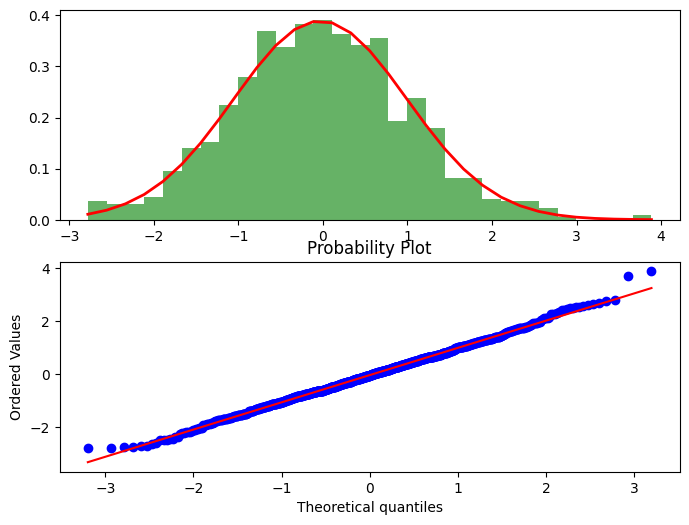

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy import stats

residuals = np.random.normal(loc=0, scale=1, size=1000)

fig, ax = plt.subplots(2,1, figsize=(8,6))

count, bins, ignored = ax[0].hist(residuals, bins=30, density=True, alpha=0.6, color='g')

mu, std = norm.fit(residuals)
pdf = norm.pdf(bins, mu, std)
ax[0].plot(bins, pdf, 'r-', linewidth=2)


plt.title('Residuals distribution')

stats.probplot(residuals, dist='norm', plot=ax[1]);

### Scenario 4: Predicting time between user clicks

If users click on average every 10 seconds, what is the probability that the next click happens in the next 5 seconds.

In [30]:
from scipy.stats import expon

rate = 1/10
time = 5

prob_within_5 = expon.cdf(time, scale=1/rate)
print(f"Probablity of next click in 5 seconds: {prob_within_5:.4f}")

Probablity of next click in 5 seconds: 0.3935
